# EDA to check transformed data (only run after finishing stage 2 - data transformation)

In [1]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import albumentations as A

os.chdir('../')
%pwd

d:\Deep_Learning_Object_Detection\MLOPs\pneumonia-segmentation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'd:\\Deep_Learning_Object_Detection\\MLOPs\\pneumonia-segmentation'

In [4]:
from pneumonia_segmentation import logging

BASE_DIR = Path('artifacts/data_transformation')
SPLITS = ["train", "valid", "infer"]

def get_pairs(split):
    img_dir = BASE_DIR / split / "img"
    msk_dir = BASE_DIR / split / "msk"
    imgs = sorted(img_dir.glob("*.png"))
    msks = sorted(msk_dir.glob("*.png"))
    return list(zip(imgs, msks))

pairs = {s: get_pairs(s) for s in SPLITS}
logging.info(f"Pairs per split:")
for s, p in pairs.items():
    logging.info(f"                 {s:>6}: {len(p)}")
print(f"{"total":>6}: {sum(len(p) for p in pairs.values())}")

[2026-04-05 10:40:54,861: INFO: 2719059953: Pairs per split:]
[2026-04-05 10:40:54,861: INFO: 2719059953:                   train: 431]


[2026-04-05 10:40:54,863: INFO: 2719059953:                   valid: 58]
[2026-04-05 10:40:54,863: INFO: 2719059953:                   infer: 53]
 total: 542


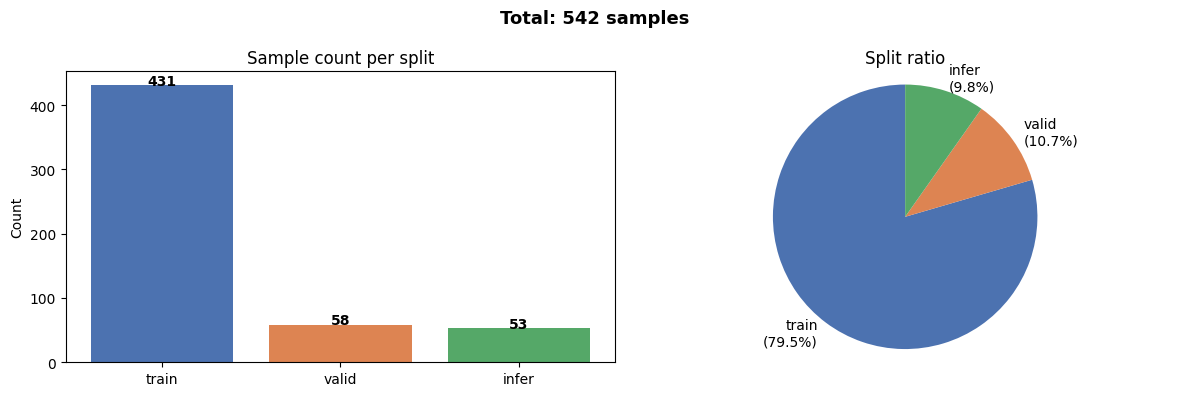

In [7]:
colors = ['#4C72B0', '#DD8452', '#55A868']
counts = {s: len(p) for s, p in pairs.items()}
total = sum(counts.values())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(counts.keys(), counts.values(), color=colors)
ax[0].set_title('Sample count per split')
ax[0].set_ylabel('Count')

for i, (k, v) in enumerate(counts.items()):
    ax[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

ax[1].pie(
    counts.values(),
    labels=[f'{k}\n({v/total*100:.1f}%)' for k, v in counts.items()],
    colors=colors,
    startangle=90
)
ax[1].axis('equal')
ax[1].set_title('Split ratio')

plt.suptitle(f'Total: {total} samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Compute coverage: ratio btw targeted and total pixels
def compute_coverage(pairs_list):
    ratios = []
    empty = 0
    for _, msk_pth in pairs_list:
        msk = cv2.imread(str(msk_pth), cv2.IMREAD_GRAYSCALE)
        binary = (msk > 0)
        ratio = binary.sum() / binary.size
        ratios.append(ratio)
        if ratio == 0:
            empty += 1
    
    return np.array(ratios), empty

[2026-04-05 11:38:27,205: INFO: 2090844512: train: mean=3.14% | median=1.67% | empty=68/431 (15.8%)]
[2026-04-05 11:38:27,248: INFO: 2090844512: valid: mean=3.29% | median=1.37% | empty=6/58 (10.3%)]
[2026-04-05 11:38:27,289: INFO: 2090844512: infer: mean=4.05% | median=1.49% | empty=7/53 (13.2%)]


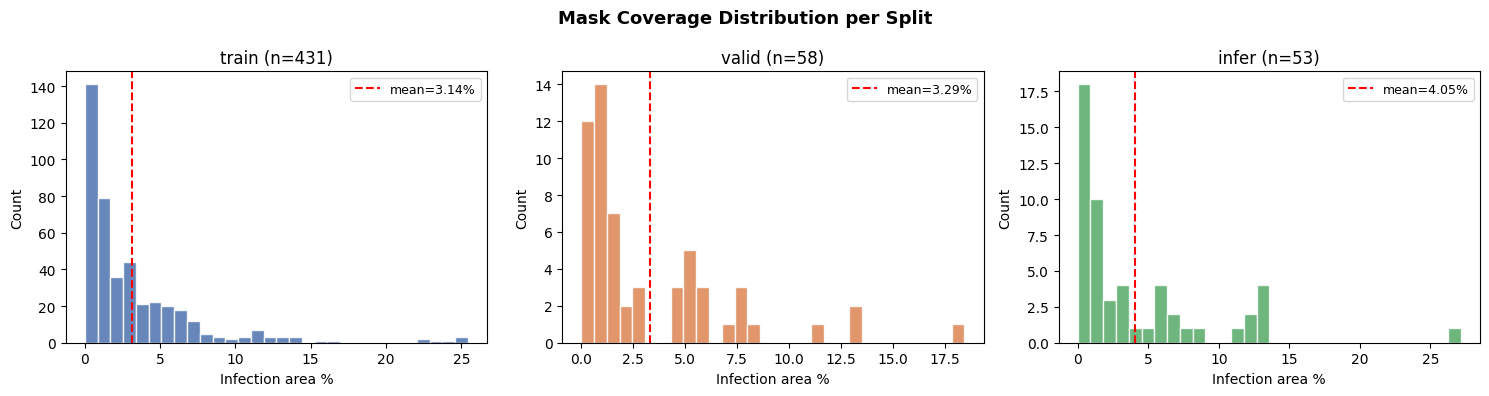

In [10]:
fig, axes = plt.subplots(1, len(SPLITS), figsize=(15, 4))

for ax, (split, color) in zip(axes, zip(SPLITS, colors)):
    ratios, empty = compute_coverage(pairs[split])
    n = len(ratios)
    
    ax.hist(ratios * 100, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(ratios.mean() * 100, color='red', linestyle='--', 
               label=f'mean={ratios.mean()*100:.2f}%')
    ax.set_title(f'{split} (n={n})')
    ax.set_xlabel('Infection area %')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    
    logging.info(f'{split}: mean={ratios.mean()*100:.2f}% ' \
                f'| median={np.median(ratios)*100:.2f}% ' \
                f'| empty={empty}/{n} ({empty/n*100:.1f}%)')

plt.suptitle('Mask Coverage Distribution per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

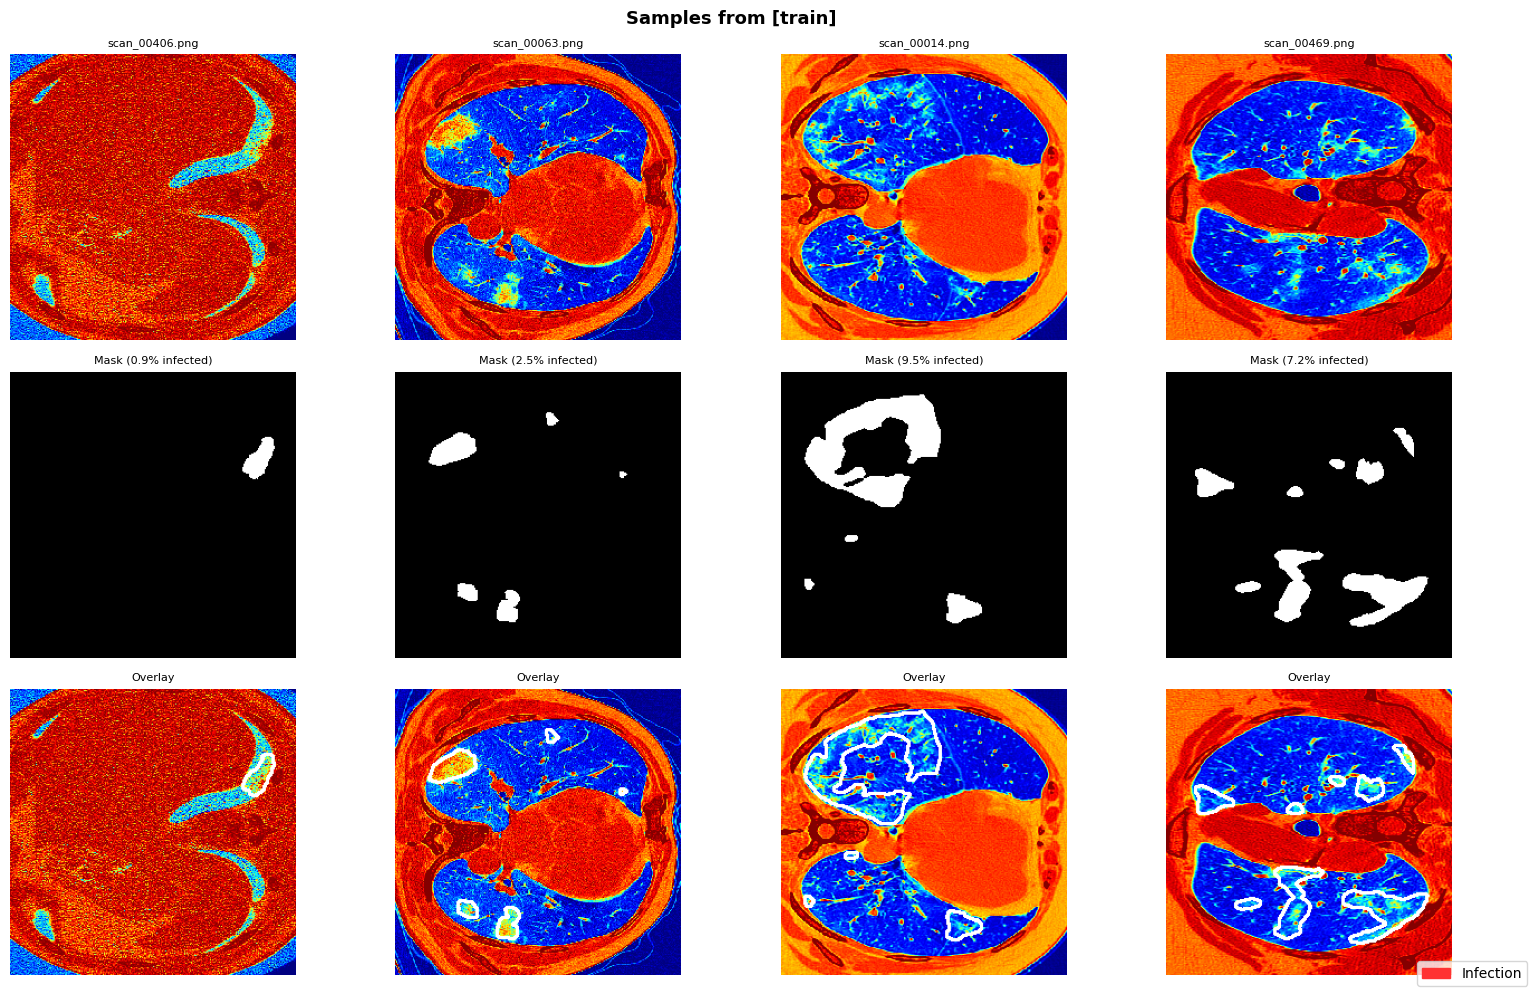

In [14]:
def overlay_msk(img_bgr, msk_gray, alpha=0.4):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    contours, _ = cv2.findContours(msk_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result = img_rgb.copy()
    cv2.drawContours(result, contours, -1, (255, 255, 255), 2)
    return result

def show_samples(split, n=4, seed=42):
    random.seed(seed)
    sample = random.sample(pairs[split], min(n, len(pairs[split])))
    
    fig, axes = plt.subplots(3, n, figsize=(4*n, 10))
    fig.suptitle(f'Samples from [{split}]', fontsize=13, fontweight='bold')
    
    for col, (img_path, msk_path) in enumerate(sample):
        img = cv2.imread(str(img_path))
        msk = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        coverage = (msk > 0).sum() / msk.size * 100
        
        axes[0, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, col].set_title(f'{img_path.name}', fontsize=8)
        axes[0, col].axis('off')
        
        axes[1, col].imshow(msk, cmap='gray')
        axes[1, col].set_title(f'Mask ({coverage:.1f}% infected)', fontsize=8)
        axes[1, col].axis('off')
        
        axes[2, col].imshow(overlay_msk(img, msk))
        axes[2, col].set_title('Overlay', fontsize=8)
        axes[2, col].axis('off')
    
    red_patch = mpatches.Patch(color='#FF3232', label='Infection')
    fig.legend(handles=[red_patch], loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

show_samples('train', n=4)

## Insights:

*After EDA, we know that:*
+ It is a clear class imbalance problem — mean coverage ~3%, median 1.67% >< where background pixels account for the majority of total pixels
+ 15.8% empty masks in train data

*Fix:*
+ Loss function → Dice + Focal
+ Empty masks 15.8% → acceptable since Dice can also handle this problem